# Exploratory Data Analysis (EDA) — Titanic Dataset


Este notebook demonstra um **fluxo de trabalho completo de Análise Exploratória de Dados** usando o clássico conjunto de dados do Titanic.

Tópicos abordados:
- Carregamento de dados
- Inspeção de dados
- Tratamento de valores ausentes
- Análise estatística
- Análise de distribuição
- Relações entre variáveis
- Insights sobre características
- Visualização

IFRS Campus Osório - Disciplina Frameworks de Software


## 1. Importar Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 2. Carregar o conjunto de dados
O conjunto de dados do Titanic está disponível na biblioteca Seaborn.

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Estrutura do Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## 4. Resumo Estatístico

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 5. Valores Ausentes

In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 6. Distribuição de Sobrevivência

In [7]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

## 7. Taxa de Sobrevivência por Sexo

In [8]:
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

## 8. Taxa de Sobrevivência por Classe de Passageiro

In [9]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

 ## 9. Distribuição por idade

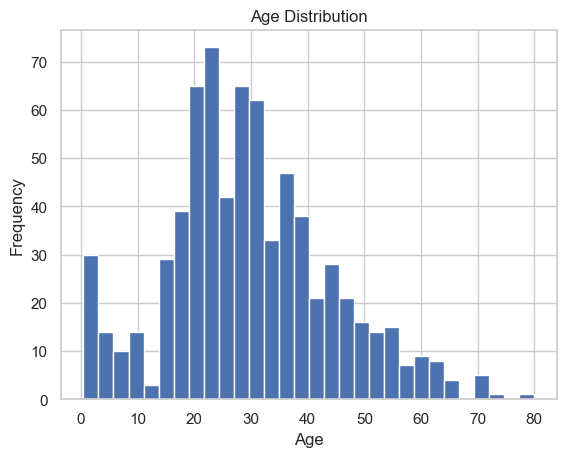

In [10]:
plt.hist(df['age'].dropna(), bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## 10. Distribuição por Tarifas

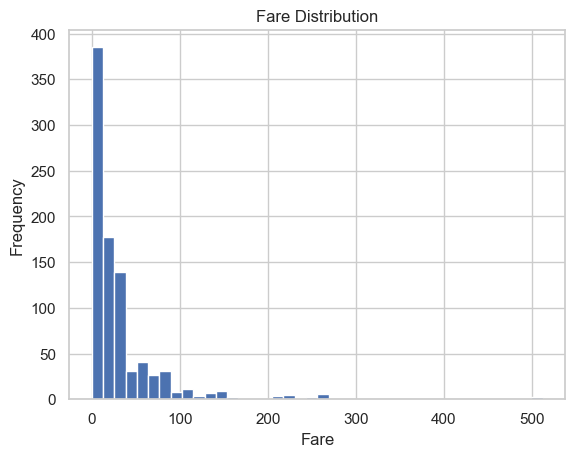

In [11]:
plt.hist(df['fare'], bins=40)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

## 11.  Visualização - Sobrevivência por Sexo

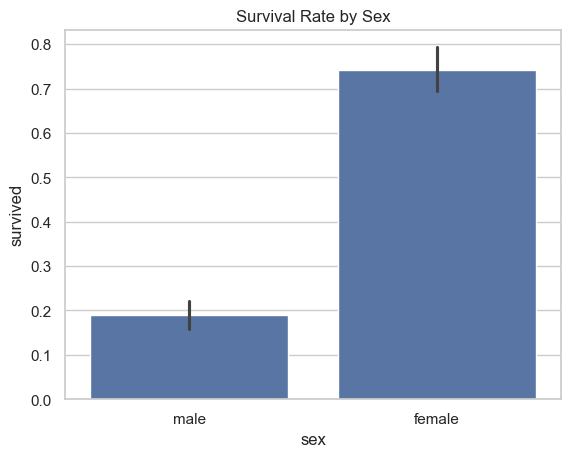

In [12]:
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

## 12. Sobrevivência por Classe de Passageiro

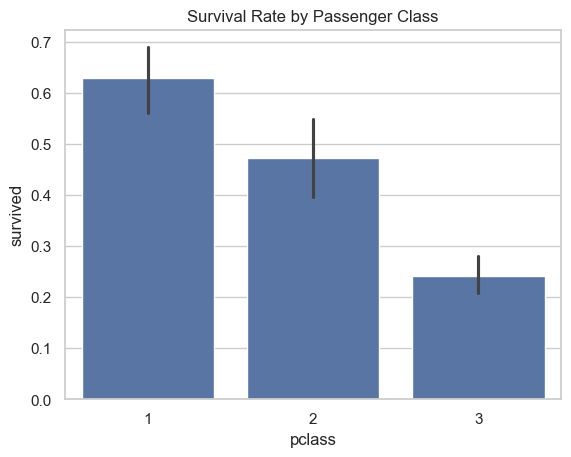

In [13]:
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

## 13. Dispersão entre Idade e Tarifa

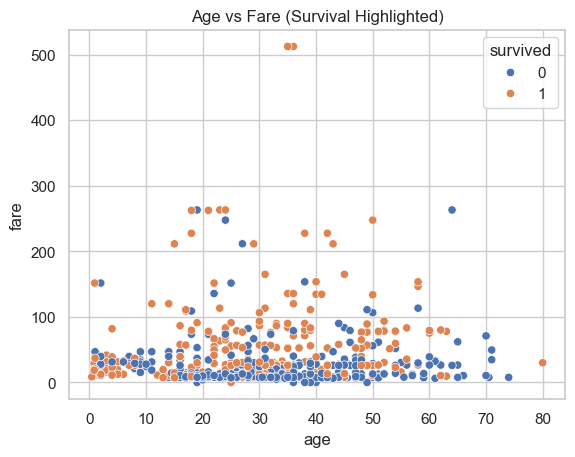

In [14]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Age vs Fare (Survival Highlighted)')
plt.show()

## 14. Matriz de Correlação

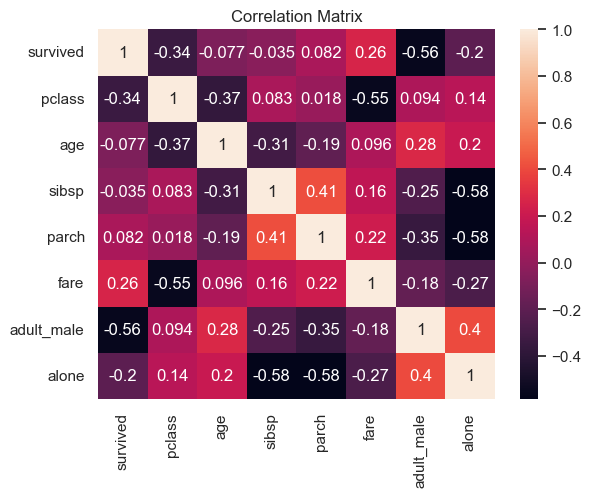

In [15]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

## 15. Principais insights

Resultados típicos deste conjunto de dados:

- As mulheres apresentaram uma taxa de sobrevivência significativamente maior.

- Passageiros da primeira classe sobreviveram com mais frequência.

- Tarifas de passagens mais altas correlacionam-se com maior probabilidade de sobrevivência.

- A idade, por si só, não é um forte preditor, mas crianças apresentaram taxas de sobrevivência mais altas.

Essas observações são comumente utilizadas na construção de modelos preditivos de sobrevivência.